In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, mixed_precision
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Setup Kaggle Credentials (REPLACE WITH YOURS)
os.environ['KAGGLE_USERNAME'] = "jayantm23"
os.environ['KAGGLE_KEY'] = "KGAT_eeff9980c304afa374d0b930c880e352"

# 3. Enable Mixed Precision (Cuts VRAM usage in half)
mixed_precision.set_global_policy('mixed_float16')

Mounted at /content/drive


In [2]:
# 1. Upgrade Kaggle and Download Dataset
!pip install -q --upgrade kaggle
!kaggle datasets download -d anirudhcv/labeled-optical-coherence-tomography-oct

# 2. Extract and overwrite silently
!unzip -q -o labeled-optical-coherence-tomography-oct.zip -d dataset_v3

# 3. Clean hidden/system files (like .DS_Store)
!find ./dataset_v3 -type f ! -iname "*.jpeg" ! -iname "*.jpg" ! -iname "*.png" -delete
print("Dataset downloaded and cleaned!")

Dataset URL: https://www.kaggle.com/datasets/anirudhcv/labeled-optical-coherence-tomography-oct
License(s): unknown
100% 6.70G/6.70G [01:33<00:00, 76.7MB/s]

Dataset downloaded and cleaned!


In [3]:
base_path = './dataset_v3'
train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')
test_dir = os.path.join(base_path, 'test')

# Fallback pathing just in case of nested folders
if not os.path.exists(train_dir):
    for root, dirs, f in os.walk(base_path):
        if 'train' in dirs and 'val' in dirs and 'test' in dirs:
            train_dir = os.path.join(root, 'train')
            val_dir = os.path.join(root, 'val')
            test_dir = os.path.join(root, 'test')
            break

batch_size = 32
img_height, img_width = 224, 224

print("Loading Training Data...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, label_mode='categorical', image_size=(img_height, img_width), batch_size=batch_size)

print("\nLoading Validation Data...")
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, label_mode='categorical', image_size=(img_height, img_width), batch_size=batch_size)

print("\nLoading Testing Data...")
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, label_mode='categorical', image_size=(img_height, img_width), batch_size=batch_size, shuffle=False)

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Define Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

Loading Training Data...
Found 76515 files belonging to 4 classes.

Loading Validation Data...
Found 21861 files belonging to 4 classes.

Loading Testing Data...
Found 10933 files belonging to 4 classes.


In [4]:
# 1. Load Base Model (Frozen)
base_model = EfficientNetB0(input_shape=(img_height, img_width, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# 2. Build Custom Top Layers
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(4, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

# 3. Define Metrics
metrics_list = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

# 4. Compile Phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=metrics_list
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [5]:
# Save path in your Drive
drive_save_path = "/content/drive/MyDrive/UGP-seond-try-model.keras"

callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(filepath=drive_save_path, save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6)
]

print("Starting Phase 1: Training top layers...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_list
)

Starting Phase 1: Training top layers...
Epoch 1/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 363s 136ms/step - accuracy: 0.8061 - auc: 0.9478 - loss: 0.5717 - precision: 0.8316 - recall: 0.7818 - val_accuracy: 0.8830 - val_auc: 0.9784 - val_loss: 0.3402 - val_precision: 0.8997 - val_recall: 0.8658 - learning_rate: 0.0010
Epoch 2/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 318s 133ms/step - accuracy: 0.8242 - auc: 0.9561 - loss: 0.5124 - precision: 0.8479 - recall: 0.8007 - val_accuracy: 0.8822 - val_auc: 0.9783 - val_loss: 0.3417 - val_precision: 0.9018 - val_recall: 0.8623 - learning_rate: 0.0010
Epoch 3/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 320s 134ms/step - accuracy: 0.8278 - auc: 0.9574 - loss: 0.5018 - precision: 0.8510 - recall: 0.8047 - val_accuracy: 0.8745 - val_auc: 0.9754 - val_loss: 0.3685 - val_precision: 0.8912 - val_recall: 0.8603 - learning_rate: 0.0010
Epoch 4/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 304s 127ms/step - accuracy: 0.8267 - auc: 0.9580 - loss: 0.4974 - precision: 0.8511 - recall: 0.8029 

In [6]:
print("Starting Phase 2: Fine-tuning base model layers...")

# Unfreeze the base model
base_model.trainable = True

# Freeze the bottom 100 layers, leaving the rest to train
for layer in base_model.layers[:100]:
  layer.trainable = False

# Recompile with a MUCH lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=metrics_list
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_list
)

Starting Phase 2: Fine-tuning base model layers...
Epoch 1/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 540s 200ms/step - accuracy: 0.9240 - auc: 0.9876 - loss: 0.2268 - precision: 0.9260 - recall: 0.9075 - val_accuracy: 0.9572 - val_auc: 0.9939 - val_loss: 0.1442 - val_precision: 0.9584 - val_recall: 0.9561 - learning_rate: 1.0000e-04
Epoch 2/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 448s 187ms/step - accuracy: 0.9525 - auc: 0.9947 - loss: 0.1431 - precision: 0.9549 - recall: 0.9503 - val_accuracy: 0.9636 - val_auc: 0.9959 - val_loss: 0.1159 - val_precision: 0.9644 - val_recall: 0.9629 - learning_rate: 1.0000e-04
Epoch 3/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 448s 187ms/step - accuracy: 0.9589 - auc: 0.9959 - loss: 0.1224 - precision: 0.9606 - recall: 0.9569 - val_accuracy: 0.9665 - val_auc: 0.9964 - val_loss: 0.1027 - val_precision: 0.9673 - val_recall: 0.9658 - learning_rate: 1.0000e-04
Epoch 4/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 499s 186ms/step - accuracy: 0.9638 - auc: 0.9968 - loss: 0.1072 - precision: 0.

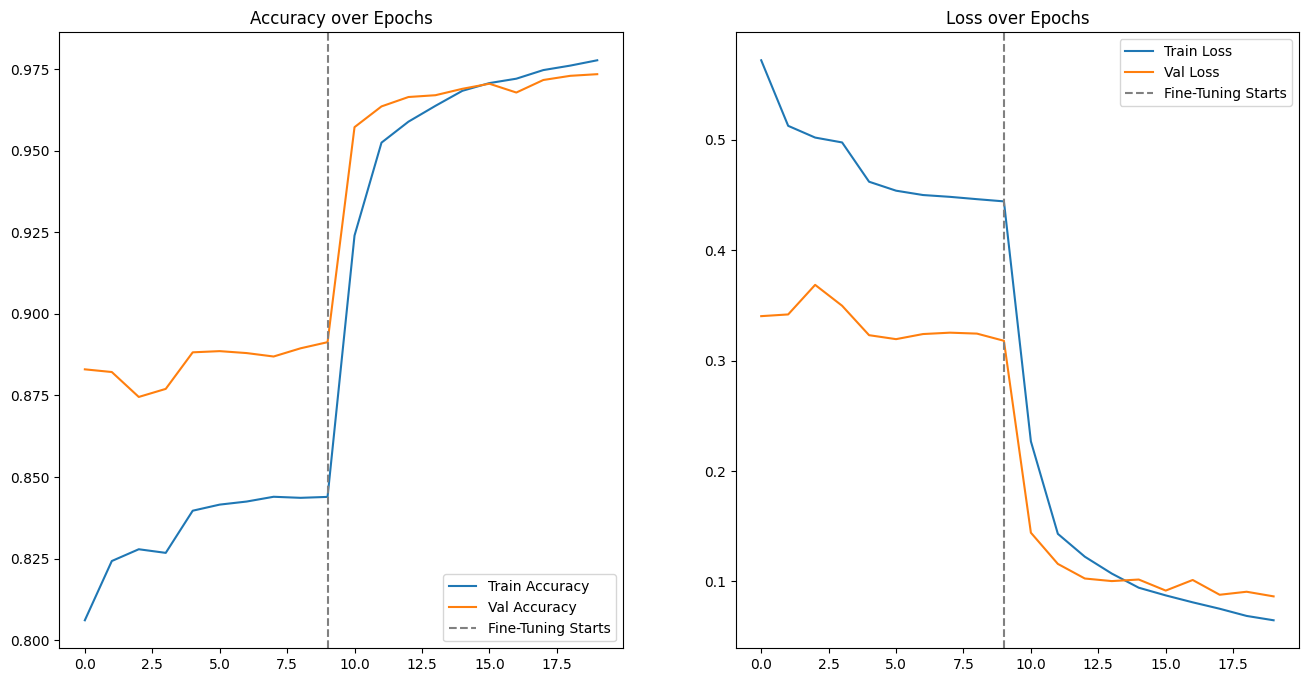


--- Final Test Set Evaluation ---
342/342 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.9707 - auc: 0.9966 - loss: 0.0967 - precision: 0.9713 - recall: 0.9705
Test Loss:      0.0967
Test Accuracy:  0.9707
Test Precision: 0.9713
Test Recall:    0.9705
Test AUC:       0.9966


In [7]:
# 1. Plot Training Curves
plt.figure(figsize=(16, 8))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=len(history.history['accuracy'])-1, color='gray', linestyle='--', label='Fine-Tuning Starts')
plt.legend(loc='lower right')
plt.title('Accuracy over Epochs')

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Val Loss')
plt.axvline(x=len(history.history['loss'])-1, color='gray', linestyle='--', label='Fine-Tuning Starts')
plt.legend(loc='upper right')
plt.title('Loss over Epochs')
plt.show()

# 2. Final Evaluation on Test Set
print("\n--- Final Test Set Evaluation ---")
test_results = model.evaluate(test_ds)
print(f"Test Loss:      {test_results[0]:.4f}")
print(f"Test Accuracy:  {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall:    {test_results[3]:.4f}")
print(f"Test AUC:       {test_results[4]:.4f}")